In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from core import run_coverage
from config import RESULTS_DIR
from coverage_analysis import (
    run_coverage_setups, parse_coverage_setups,
    plot_coverage_results_by_pair, plot_coverage_convergence
)


In [2]:
n_sim = 10000
alpha = 0.05
target_coverage = 1.0 - alpha
param_name = 'sr'
param_values = [0.5, 1.0 , 1.5]
dgps = ["iid_normal", "iid_t5", "ar1_phi06_normal", "ar1_phi-06_normal"]
models = ["iid_normal", "iid_student_t", "iid_nonnormal", "ar1_normal"]
th_moments = False


In [3]:
run_coverage_setups(n=n_sim, alpha=alpha,
                    param_name=param_name, param_values=param_values,
                    dgps=dgps, models=models,
                    th_moments=th_moments)

1 / 3

  Coverage Study  |  nominal=0.95  tol=+/-0.03

  EMPIRICAL COVERAGE
  DGP                                   ar1_normal       iid_nonnormal          iid_normal       iid_student_t
  ------------------------------------------------------------------------------------------------------------
  ar1_phi-06_normal                       0.950 OK            0.997 !!            0.997 !!            0.995 !!
  ar1_phi06_normal                        0.942 OK            0.685 !!            0.688 !!            0.684 !!
  iid_normal                              0.944 OK            0.950 OK            0.947 OK            0.951 OK
  iid_t5                                  0.924 OK            0.942 OK            0.924 OK            0.946 OK

  BIAS of SR_hat
  DGP                                   ar1_normal       iid_nonnormal          iid_normal       iid_student_t
  ------------------------------------------------------------------------------------------------------------
  ar1_phi-06_norma

In [6]:
filtered_dgps = ["iid_normal", "iid_t5"]
filtered_models = ["iid_normal", "iid_student_t"]
df_results = parse_coverage_setups(n=n_sim,
                                   dgps=filtered_dgps, models=filtered_models,
                                   param_name=param_name, param_values=param_values)


=== Combined Results Table ===
 sr   dgp_name    avar_model  nominal_coverage  coverage     bias     rmse
0.5 iid_normal    iid_normal              0.95    0.9469 0.000547 0.048045
0.5 iid_normal iid_student_t              0.95    0.9506 0.000884 0.047307
0.5     iid_t5    iid_normal              0.95    0.9244 0.002877 0.052589
0.5     iid_t5 iid_student_t              0.95    0.9462 0.001822 0.053276
1.0 iid_normal    iid_normal              0.95    0.9489 0.001502 0.055616
1.0 iid_normal iid_student_t              0.95    0.9519 0.001543 0.054681
1.0     iid_t5    iid_normal              0.95    0.8672 0.005127 0.072258
1.0     iid_t5 iid_student_t              0.95    0.9377 0.004120 0.072929
1.5 iid_normal    iid_normal              0.95    0.9476 0.002456 0.066245
1.5 iid_normal iid_student_t              0.95    0.9513 0.002201 0.065145
1.5     iid_t5    iid_normal              0.95    0.8218 0.007376 0.096501
1.5     iid_t5 iid_student_t              0.95    0.9314 0.006417 0.0

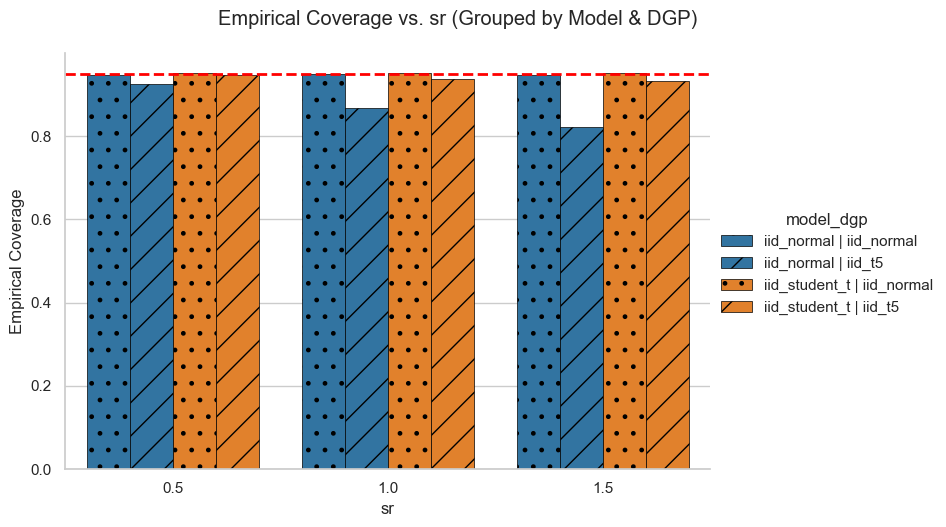

In [7]:
plot_coverage_results_by_pair(df_results, param_name=param_name, target_val=target_coverage)

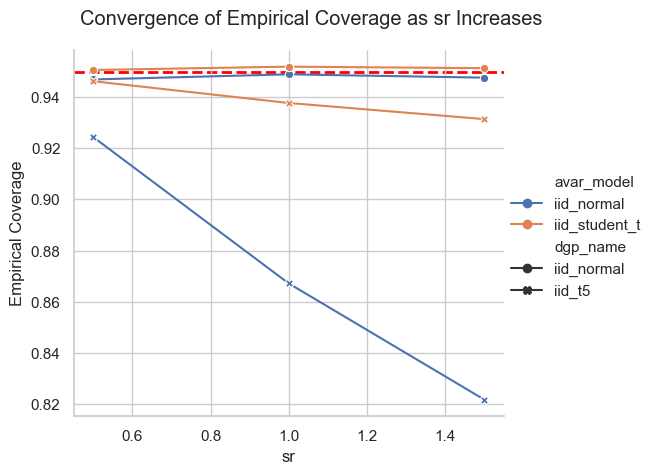

In [8]:
plot_coverage_convergence(df_results, param_name=param_name, target_val=target_coverage)